# Pima Indians Diabetes Prediction

This notebook explores the Pima Indians Diabetes Database to build and evaluate logistic regression models for predicting diabetes. The process involves data loading, comprehensive exploratory data analysis, data cleaning, model training, evaluation, and feature selection.

## Resources

*   **Data Source:** [Kaggle - Pima Indians Diabetes Database](https://www.kaggle.com/uciml/pima-indians-diabetes-database)

In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error, r2_score, explained_variance_score
import kagglehub
import os

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

csv_file_path = os.path.join(path, "diabetes.csv")
d_data = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


## Target Variable Distribution

This histogram illustrates the distribution of the target variable, 'Outcome.' In this dataset, a value of '1' signifies the presence of diabetes, while '0' indicates the absence of diabetes. This visualization provides an immediate understanding of the class imbalance within the dataset.

<Axes: >

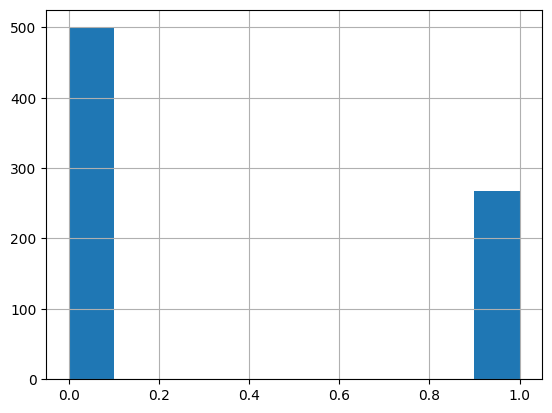

In [5]:
d_data.Outcome.hist()

In [6]:
d_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
d_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
d_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
d_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Missing Value Assessment

Upon initial inspection, the dataset was found to contain no explicit missing values across all features, indicating a complete data record for the provided observations. This completeness simplifies the preprocessing stage by obviating the need for imputation strategies for traditional null values.

<Axes: >

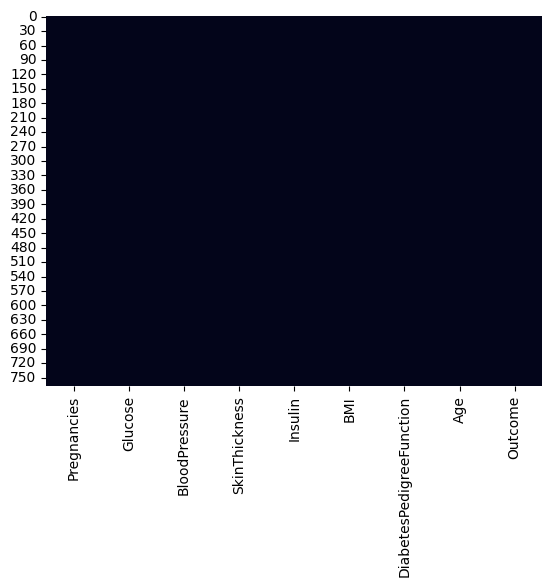

In [10]:
sns.heatmap(d_data.isnull(), cbar=False)

## Data Cleaning: Handling Implausible Values

To ensure the robustness and reliability of the predictive model, a critical data cleaning step involved.Specifically, observations where key metabolic and physiological measurements such as `Glucose`, `BloodPressure`, `Insulin`, and `BMI` were recorded as zero were removed, as these values are clinically unrealistic and could significantly distort model training and interpretability. Additionally, extreme outlier values for `Pregnancies` (e.g., greater than 15) were also excluded to align with typical biological ranges and prevent undue influence on the model from rare or erroneous data points.

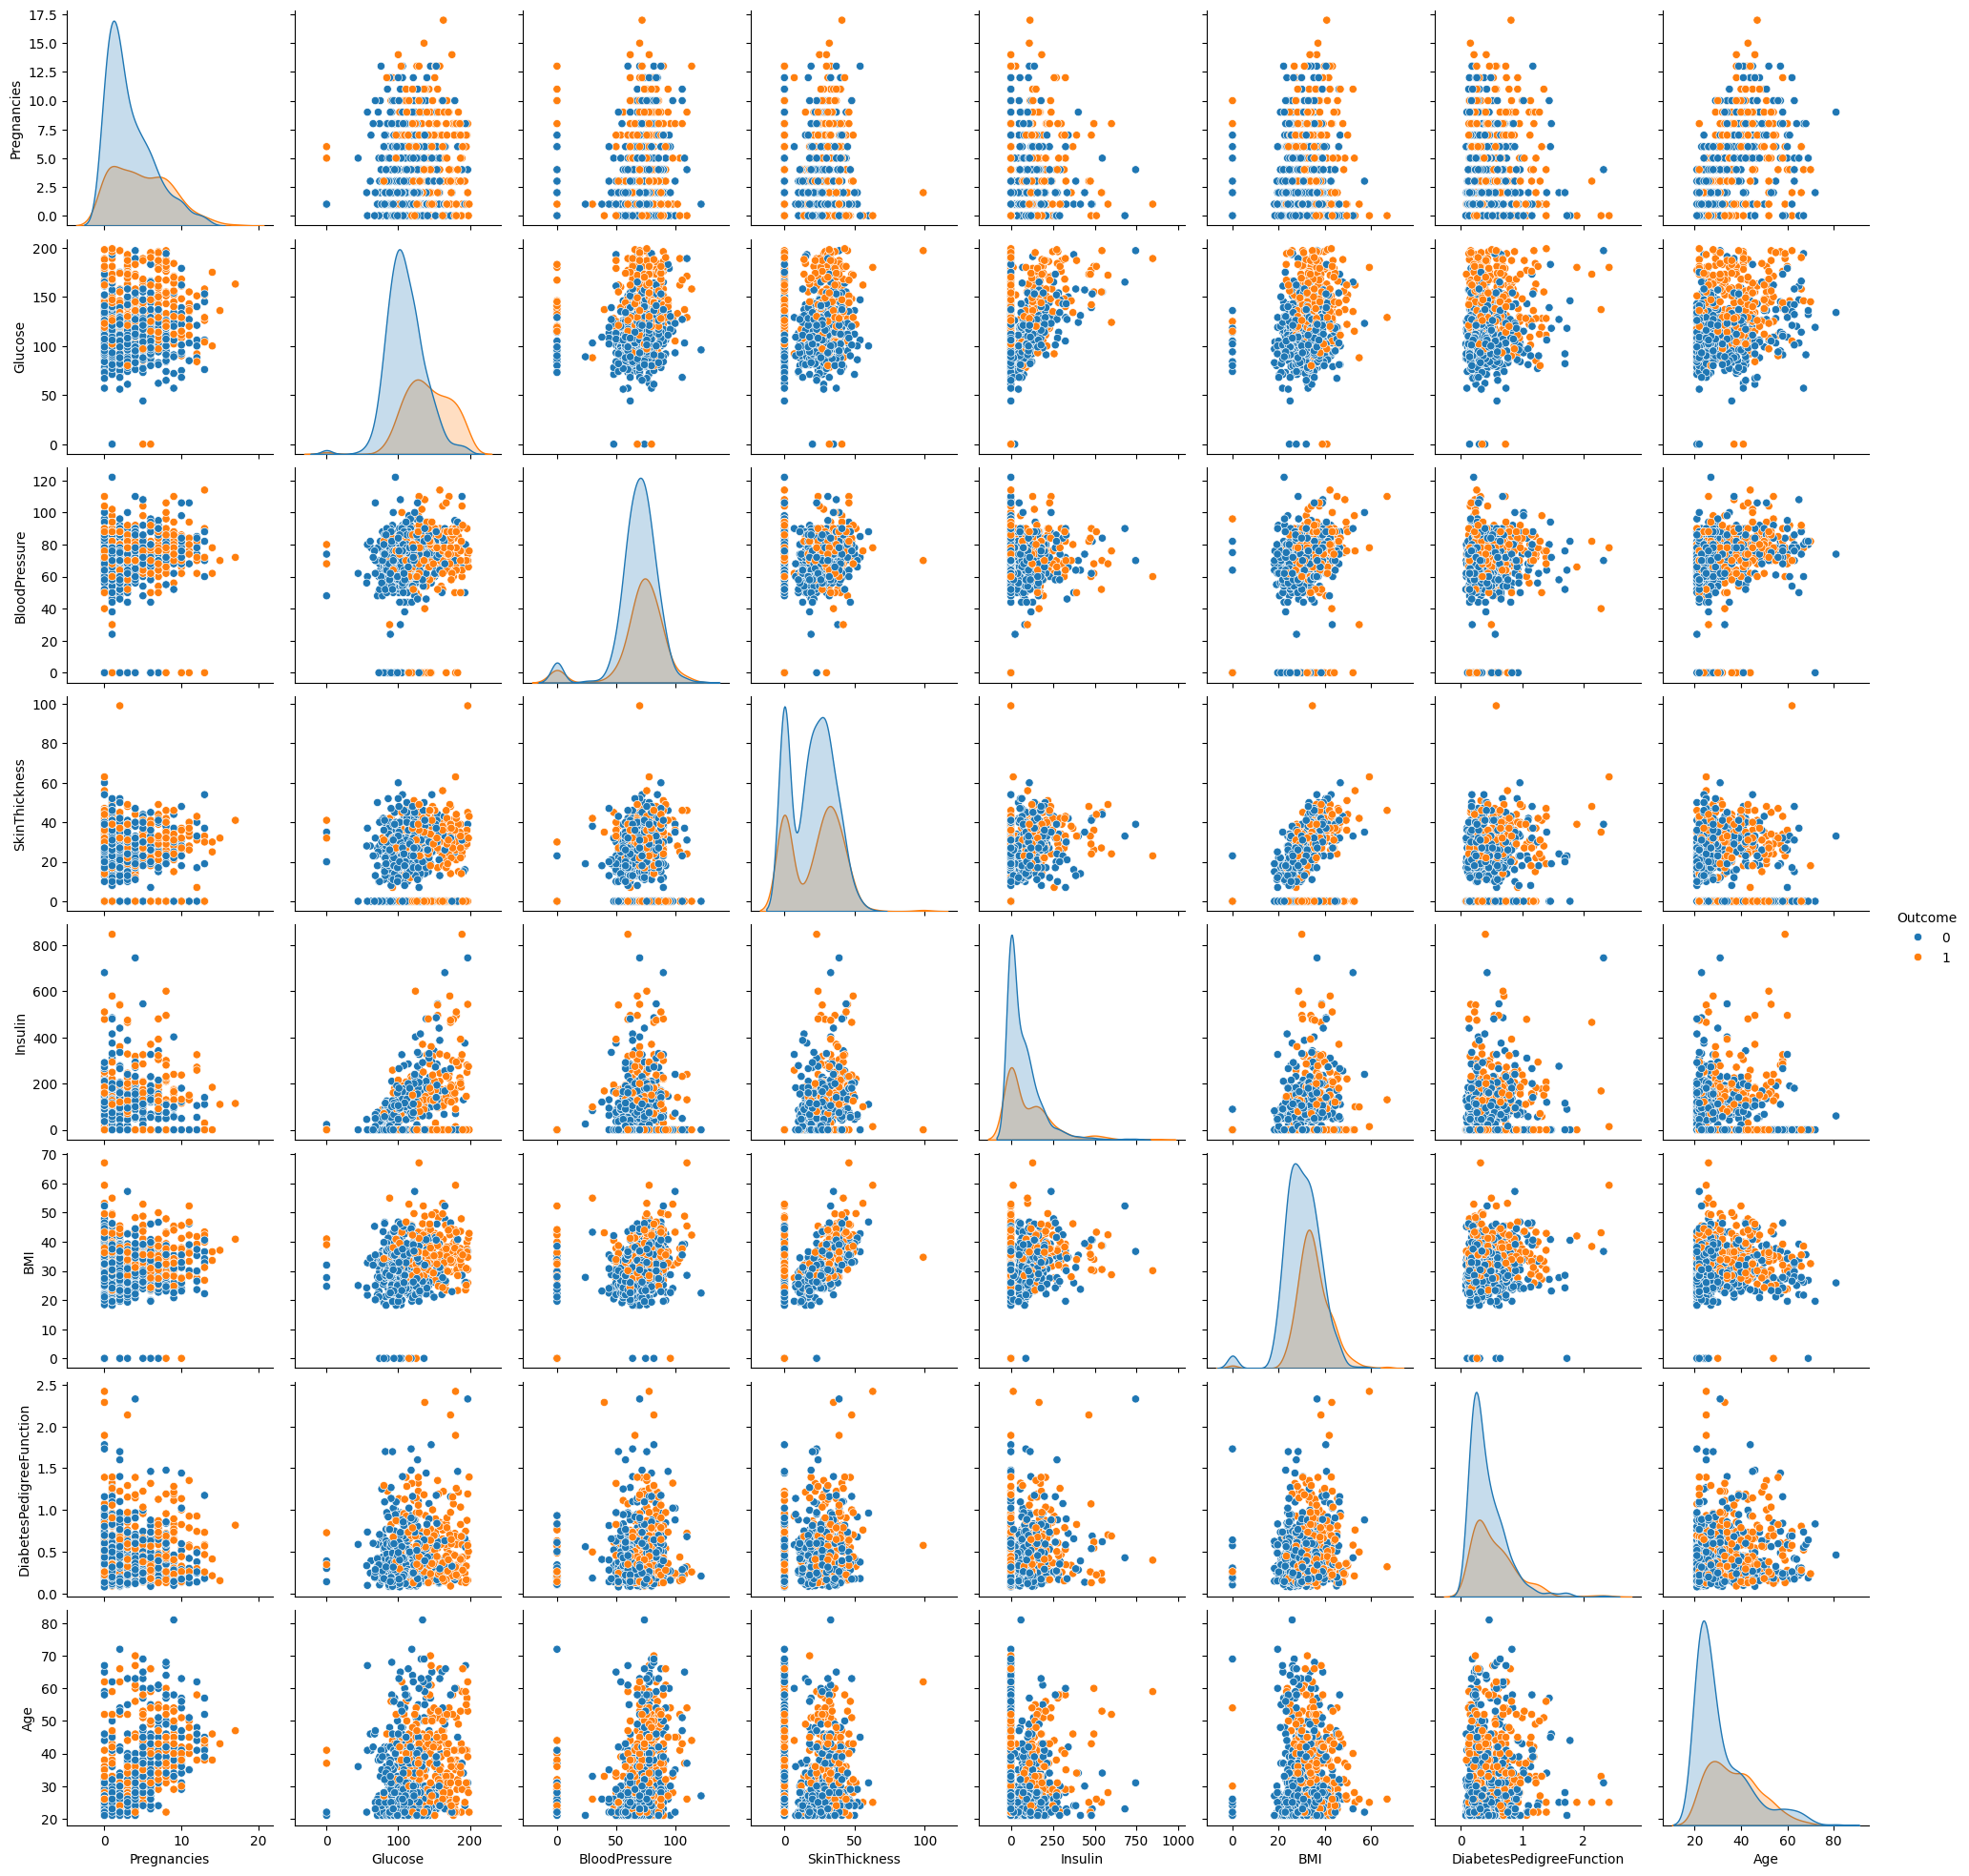

In [11]:
sns.pairplot(d_data, hue = 'Outcome')

In [12]:
d_data.drop(d_data[d_data['Glucose'] < 5 ].index, inplace=True)
d_data.drop(d_data[d_data['BloodPressure'] < 5].index, inplace=True)
d_data.drop(d_data[d_data['Insulin'] < 5 ].index, inplace=True)
d_data.drop(d_data[d_data['BMI'] < 5 ].index, inplace=True)
d_data.drop(d_data[d_data['Pregnancies'] > 15 ].index, inplace=True)

## Multicollinearitys Found

During exploratory data analysis, visualizations revealed potential multicollinearity among several features, more specifically `SkinThickness`, `BMI`, `Insulin`, and `Glucose`. Multicollinearity occurs when independent variables in a regression model are highly correlated with each other. This can significantly impact the stability and interpretability of the model coefficients, making it difficult to ascertain the individual effect of each predictor on the outcome variable.

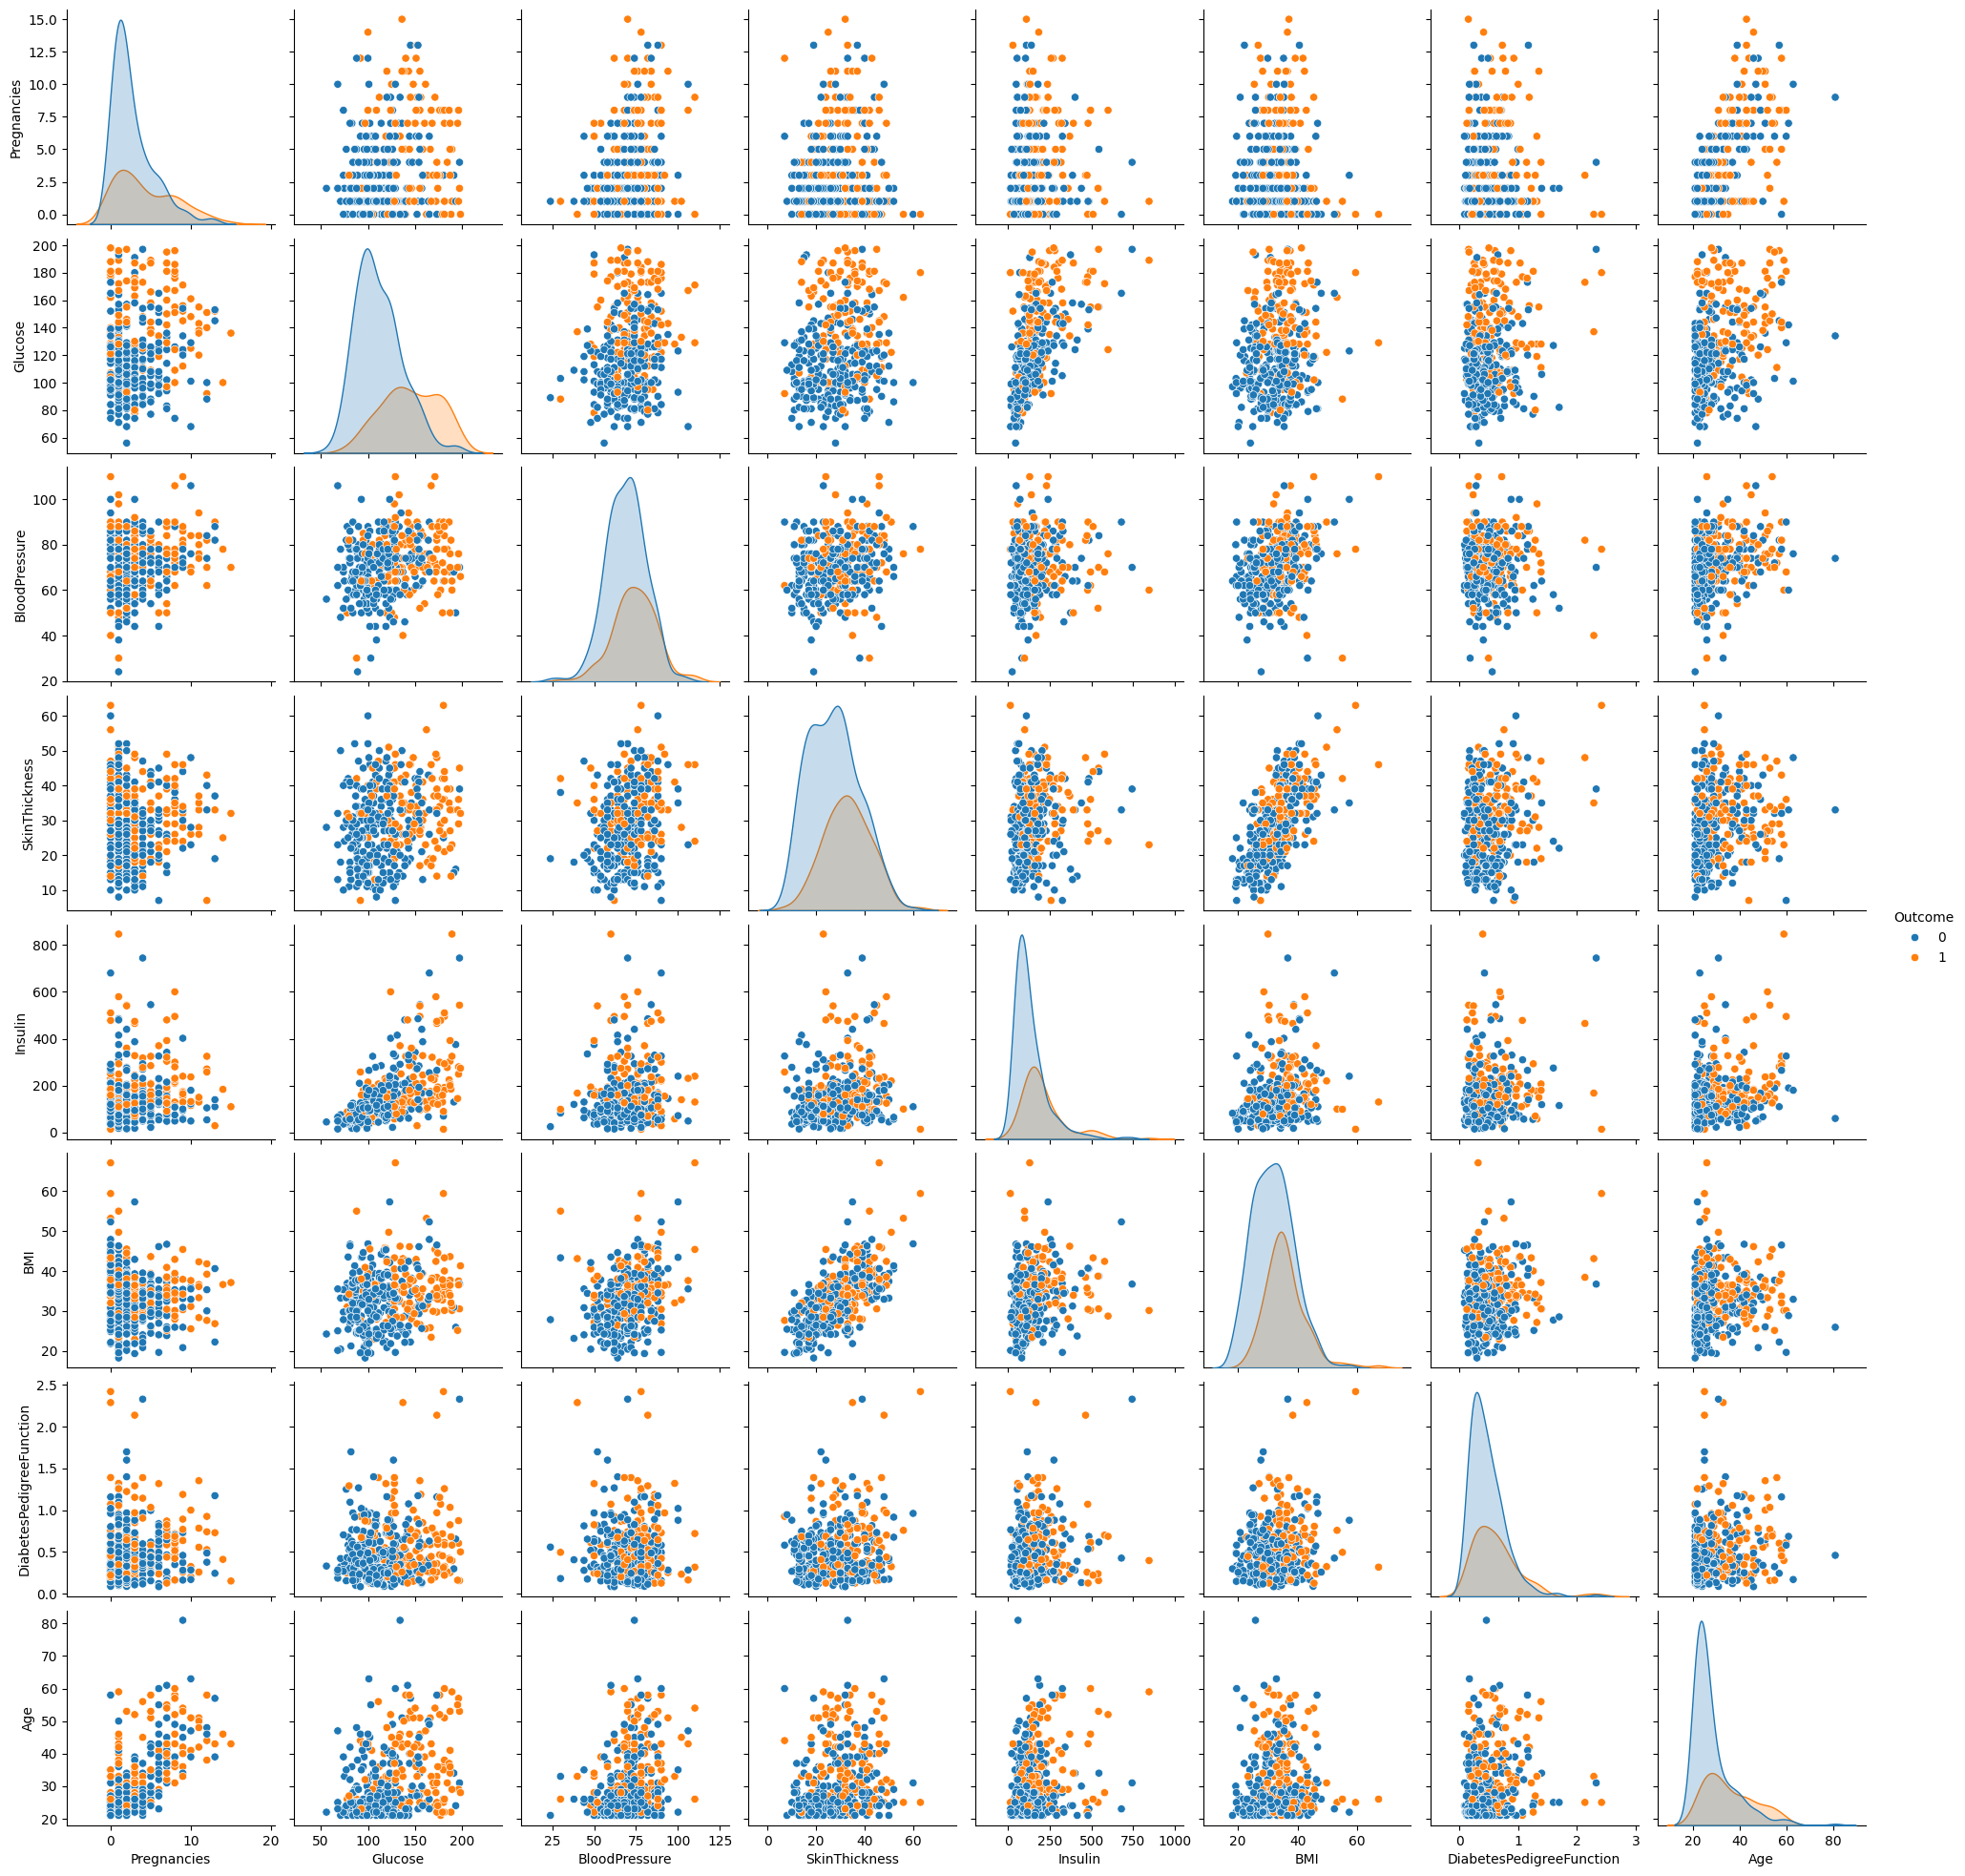

In [13]:
sns.pairplot(d_data, hue = 'Outcome')

In [14]:
d_data['Outcome'] =  d_data['Outcome'].astype('category',copy=False)

In [15]:
d_data_clean = pd.get_dummies(d_data, drop_first=True)

In [16]:
d_data_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,391.000000,391.000000,391.000000,391.00000,391.000000,391.000000,391.000000,391.000000
mean,3.265985,122.524297,70.659847,29.11509,156.163683,33.066240,0.522294,30.823529
std,3.139630,30.832447,12.511918,10.51273,118.974847,7.025502,0.345609,10.181031
min,0.000000,56.000000,24.000000,7.00000,14.000000,18.200000,0.085000,21.000000
25%,1.000000,99.000000,62.000000,21.00000,76.500000,28.400000,0.269500,23.000000
50%,2.000000,119.000000,70.000000,29.00000,126.000000,33.200000,0.447000,27.000000
75%,5.000000,143.000000,78.000000,36.50000,190.000000,37.050000,0.684500,36.000000
max,15.000000,198.000000,110.000000,63.00000,846.000000,67.100000,2.420000,81.000000


In [17]:
d_data_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome_1
3,1,89,66,23,94,28.1,0.167,21,False
4,0,137,40,35,168,43.1,2.288,33,True
6,3,78,50,32,88,31.0,0.248,26,True
8,2,197,70,45,543,30.5,0.158,53,True
13,1,189,60,23,846,30.1,0.398,59,True


## Data Splitting and Model Initialization

This section outlines the process of preparing the dataset for model training and evaluation. The data is partitioned into training and testing sets, and a logistic regression model is initialized to predict diabetes.

### Why Data Splitting?
The dataset is divided into a training set and a test set using a 70/30 ratio. The training set (70% of the data) will be used to train the logistic regression model, while the test set (30% of the data) will be reserved for evaluating the model's performance on unseen data. This split helps in assessing the model's generalization capabilities.


In [18]:
X = d_data_clean.drop('Outcome_1', axis=1)
y = d_data_clean['Outcome_1']

In [19]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
6,3,78,50,32,88,31.0,0.248,26
8,2,197,70,45,543,30.5,0.158,53
13,1,189,60,23,846,30.1,0.398,59


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [21]:
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(solver='liblinear')

logmodel.fit(X_train,y_train)

LogisticRegression(solver='liblinear')

In [22]:
y_pred = logmodel.predict(X_test)

**Calculating the confusion matrix**
- True Negatives (top-left): Correctly predicted non-diabetic cases.
- False Positives (top-right): Incorrectly predicted diabetic cases (Type I error).
- False Negatives (bottom-left): Incorrectly predicted non-diabetic cases (Type II error).
- True Positives (bottom-right): Correctly predicted diabetic cases.

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

The confusion matrix provides a detailed breakdown of correct and incorrect classifications:
# # Calculate the confusion matrix
# - True Negatives (top-left): Correctly predicted non-diabetic cases.
# - False Positives (top-right): Incorrectly predicted diabetic cases (Type I error).
# - False Negatives (bottom-left): Incorrectly predicted non-diabetic cases (Type II error).
# - True Positives (bottom-right): Correctly predicted diabetic cases.
confusion_matrix(y_test,y_pred)

array([[75, 13],
       [12, 18]])

**Classification Report**

This report provides key classification metrics: precision, recall, f1-score, and support
for each class (non-diabetic and diabetic), along with overall accuracy, macro average, and weighted average.
- Precision: The proportion of positive identifications that were actually correct.
- Recall (Sensitivity): The proportion of actual positives that were identified correctly.
- F1-Score: The harmonic mean of precision and recall, providing a single metric that balances both.
- Support: The number of actual occurrences of the class in the specified dataset.

In [24]:
# Print the classification report
# This report provides key classification metrics: precision, recall, f1-score, and support
# for each class (non-diabetic and diabetic), along with overall accuracy, macro average, and weighted average.
# - Precision: The proportion of positive identifications that were actually correct.
# - Recall (Sensitivity): The proportion of actual positives that were identified correctly.
# - F1-Score: The harmonic mean of precision and recall, providing a single metric that balances both.
# - Support: The number of actual occurrences of the class in the specified dataset.
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.86      0.85      0.86        88
        True       0.58      0.60      0.59        30

    accuracy                           0.79       118
   macro avg       0.72      0.73      0.72       118
weighted avg       0.79      0.79      0.79       118



In [25]:
logmodel.coef_

array([[ 0.10112842,  0.0231653 , -0.02408073,  0.00925392,  0.00093537,
         0.02766532,  0.39409963,  0.01532967]])

## Feature Significance Analysis

This section examines the p-values for each feature from the initial logistic regression model. A common threshold for statistical significance (alpha) is 0.05. Features with p-values greater than this threshold are considered not statistically significant, suggesting they do not have a meaningful impact on the `Outcome` variable in this model context.

From the model summary, we observe that the `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, and `Age` features exhibit p-values significantly higher than 0.05. Their inclusion in the model, therefore, might introduce noise or reduce the model's interpretability without providing substantial predictive power.

**Next Step:** To address this, we will proceed to create a new, refined model by excluding these statistically insignificant features. This approach aims to improve model parsimony and focus on features that demonstrate a statistically significant relationship with diabetes prediction.

In [26]:
import statsmodels.api as sm
logit_model=sm.Logit(y_train, X_train)
logmodel_2=logit_model.fit()
print(logmodel_2.summary2())

Optimization terminated successfully.
         Current function value: 0.586270
         Iterations 5
                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    Outcome_1          Pseudo R-squared:   0.105     
Date:                  2026-05-14 16:17   AIC:                336.1033  
No. Observations:      273                BIC:                364.9790  
Df Model:              7                  Log-Likelihood:     -160.05   
Df Residuals:          265                LL-Null:            -178.79   
Converged:             1.0000             LLR p-value:        3.7983e-06
No. Iterations:        5.0000             Scale:              1.0000    
------------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------
Pregnancies               0.1230   0.0581  2.1185 0

## Model Refinement: Feature Selection and Impact Assessment

Following the p-value analysis, features with a significance level above 0.05 (`SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, and `Age`) were excluded from the dataset

The ROC AUC scores for both the original and the reduced models were calculated and compared:

*   **Original Model ROC AUC:** `0.766`
*   **Reduced Model ROC AUC:** `0.751`

The slight decrease in ROC AUC (from 0.766 to 0.751) suggests that while some predictive power was marginally affected, the model's overall performance remains robust. The benefits of a simpler, more interpretable model with fewer features often outweigh a minimal drop in performance, especially if the removed features were contributing more noise.

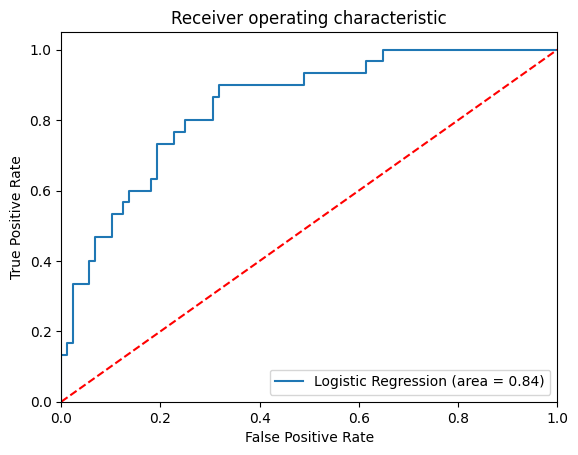

In [27]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate the Receiver Operating Characteristic (ROC) AUC score.
# ROC AUC measures the ability of the model to distinguish between classes.
# An AUC of 0.5 suggests no discrimination, while an AUC of 1.0 suggests perfect discrimination.
logit_roc_auc = roc_auc_score(y_test, logmodel.predict_proba(X_test)[:,1])

# Calculate the False Positive Rate (fpr), True Positive Rate (tpr), and thresholds
# for the ROC curve. The ROC curve plots TPR vs. FPR at various threshold settings.
fpr, tpr, thresholds = roc_curve(y_test, logmodel.predict_proba(X_test)[:,1])

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--', label='Random Classifier') # Reference line for a random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True) # Add grid for better readability
plt.savefig('Log_ROC') # Save the plot to a file
plt.show() # Display the plot

In [28]:
d_data['Outcome'] = pd.to_numeric(d_data['Outcome'])

print('Chance Rate of Obtaining Diabetes: ', d_data.Outcome.mean())

Chance Rate of Obtaining Diabetes:  0.329923273657289


In [29]:
import statsmodels.api as sm
import pandas as pd

logit_model = sm.Logit(y_train, X_train)
logmodel_result = logit_model.fit()

p_values = logmodel_result.pvalues
a = 0.05

insignificant_features = p_values[p_values > a].index.tolist()

X_train_reduced = X_train.drop(columns=insignificant_features)
X_test_reduced = X_test.drop(columns=insignificant_features)

logit_model_reduced = sm.Logit(y_train, X_train_reduced)
logmodel_reduced_result = logit_model_reduced.fit()

print(logmodel_reduced_result.summary2())


from sklearn.metrics import roc_auc_score

logit_roc_auc_original = roc_auc_score(y_test, logmodel_result.predict(X_test))
logit_roc_auc_reduced = roc_auc_score(y_test, logmodel_reduced_result.predict(X_test_reduced))

print("Original Model ROC AUC:", logit_roc_auc_original)
print("Reduced Model ROC AUC:", logit_roc_auc_reduced)

Optimization terminated successfully.
         Current function value: 0.586270
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.593990
         Iterations 5
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: Outcome_1        Pseudo R-squared: 0.093     
Date:               2026-05-14 16:17 AIC:              330.3185  
No. Observations:   273              BIC:              341.1469  
Df Model:           2                Log-Likelihood:   -162.16   
Df Residuals:       270              LL-Null:          -178.79   
Converged:          1.0000           LLR p-value:      5.9692e-08
No. Iterations:     5.0000           Scale:            1.0000    
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
Pregnancies        0.1349   0.

In [30]:
import statsmodels.api as sm
import pandas as pd
from sklearn.metrics import classification_report

y_pred_reduced = logmodel_reduced_result.predict(X_test_reduced)

y_pred_classes = (y_pred_reduced > 0.5).astype(int)

report = classification_report(y_test, y_pred_classes)
print(report)

              precision    recall  f1-score   support

       False       0.85      0.84      0.85        88
        True       0.55      0.57      0.56        30

    accuracy                           0.77       118
   macro avg       0.70      0.70      0.70       118
weighted avg       0.77      0.77      0.77       118



## Overall Project Outcome and Conclusion

This project aimed to predict diabetes in Pima Indian women using a logistic regression model, starting from data loading to a refined predictive model. Below is a summary of the key steps and outcomes:

### Data Loading and Initial Exploration
The dataset was successfully loaded from Kaggle. Initial EDA revealed the distribution of the target variable (`Outcome`) and provided a preliminary understanding of feature distributions.

### Data Cleaning and Preprocessing
Critical data cleaning steps were performed to address unrealistic values (e.g., '0' for Glucose, BloodPressure, Insulin, and BMI, which are physiologically impossible). These rows were removed to ensure data quality and prevent model distortion. Feature engineering included converting the `Outcome` variable to a categorical type suitable for classification tasks and one-hot encoding.

### Feature Selection and Model Refinement
A crucial step involved analyzing feature significance using `statsmodels` to identify features with p-values greater than 0.05. `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, and `Age` were identified as statistically insignificant in the initial model. These features were subsequently removed, and a new logistic regression model was trained on the reduced feature set.

### Reduced Model Performance
The reduced model showed a slight decrease in ROC AUC (to approximately 0.751). However, the trade-off for a simpler, more interpretable model with fewer features is often beneficial by reducing noise
